In [ ]:
#unzip file
#!unzip "/content/drive/MyDrive/Language Detection.csv.zip" -d "/content/drive/MyDrive/"

# https://www.kaggle.com/datasets/basilb2s/language-detection


In [ ]:
!pip install scikit-learn==1.7.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 92.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Language Detection.csv')
df.head(10)

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English
5,"[2] In ancient philosophy, natura is mostly us...",English
6,"[3][4] \nThe concept of nature as a whole, the...",English
7,During the advent of modern scientific method ...,English
8,"[5][6] With the Industrial revolution, nature ...",English
9,"However, a vitalist vision of nature, closer t...",English


In [ ]:
df.isnull().sum()

,0
Text,0
Language,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10337 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      10337 non-null  object
 1   Language  10337 non-null  object
dtypes: object(2)
memory usage: 161.6+ KB


In [ ]:
df.describe()

,Text,Language
count,10337,10337
unique,10267,17
top,mijn excuses.,English
freq,3,1385


In [ ]:
x = df['Text']
y = df['Language']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
le.classes_

array(['Arabic', 'Danish', 'Dutch', 'English', 'French', 'German',
       'Greek', 'Hindi', 'Italian', 'Kannada', 'Malayalam', 'Portugeese',
       'Russian', 'Spanish', 'Sweedish', 'Tamil', 'Turkish'], dtype=object)

In [ ]:
# Clean the text data properly
data_list = []
for text in x:
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`0-9]', '', text)
    text = re.sub(r'\[.*?\]', ' ', text)  # This properly removes anything inside square brackets
    text = text.lower()
    data_list.append(text)

# Update x to use the cleaned text
x = data_list


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y,test_size=0.2,random_state=20)

🚨 When Using a Pipeline, You Don't Need to Manually Vectorize
The whole point of a Pipeline is to automate the steps — including vectorization. When you use a pipeline like this:

In [ ]:
#from sklearn.feature_extraction.text import CountVectorizer
#cv = CountVectorizer()
#cv.fit(x_train)
#x_train = cv.transform(x_train).toarray()
#x_test = cv.transform(x_test).toarray()

In [ ]:
#from sklearn.naive_bayes import MultinomialNB
#model = MultinomialNB()
#model.fit(x_train,y_train)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

pipe.fit(x_train, y_train)


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


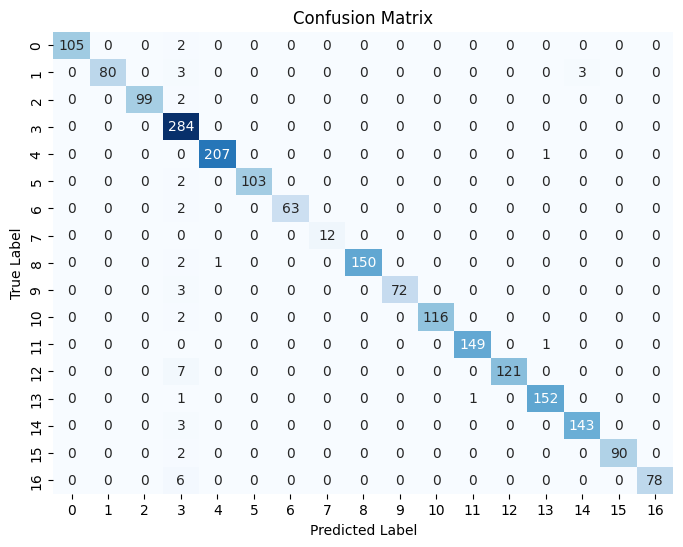

Accuracy: 0.98
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       107
           1       1.00      0.93      0.96        86
           2       1.00      0.98      0.99       101
           3       0.88      1.00      0.94       284
           4       1.00      1.00      1.00       208
           5       1.00      0.98      0.99       105
           6       1.00      0.97      0.98        65
           7       1.00      1.00      1.00        12
           8       1.00      0.98      0.99       153
           9       1.00      0.96      0.98        75
          10       1.00      0.98      0.99       118
          11       0.99      0.99      0.99       150
          12       1.00      0.95      0.97       128
          13       0.99      0.99      0.99       154
          14       0.98      0.98      0.98       146
          15       1.00      0.98      0.99        92
          16       1.00      0.93      0.96

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = pipe.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot with Seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
pipe.fit(x_train, y_train).score(x_test, y_test)

0.9787234042553191

In [ ]:
for a in [0.01, 0.1, 0.5, 1, 2, 5]:
    score = pipe.set_params(classifier__alpha=a).fit(x_train, y_train).score(x_test, y_test)
    print(f"Alpha={a} → Accuracy: {score:.4f}")


Alpha=0.01 → Accuracy: 0.9816
Alpha=0.1 → Accuracy: 0.9807
Alpha=0.5 → Accuracy: 0.9811
Alpha=1 → Accuracy: 0.9787
Alpha=2 → Accuracy: 0.9715
Alpha=5 → Accuracy: 0.9565


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__alpha': [0.01, 0.1, 0.5, 1, 2, 5, 10]
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_train, y_train)

print("Best alpha:", grid.best_params_)
print("Best accuracy on training folds:", grid.best_score_)
print("Test set accuracy:", grid.score(x_test, y_test))


Best alpha: {'classifier__alpha': 0.1}
Best accuracy on training folds: 0.979562350817209
Test set accuracy: 0.9806576402321083


In [ ]:
pipe.set_params(classifier__alpha=0.1).fit(x_train, y_train)


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [ ]:
# i am using this

pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB(alpha=0.1))
])

pipe.fit(x_train, y_train)


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


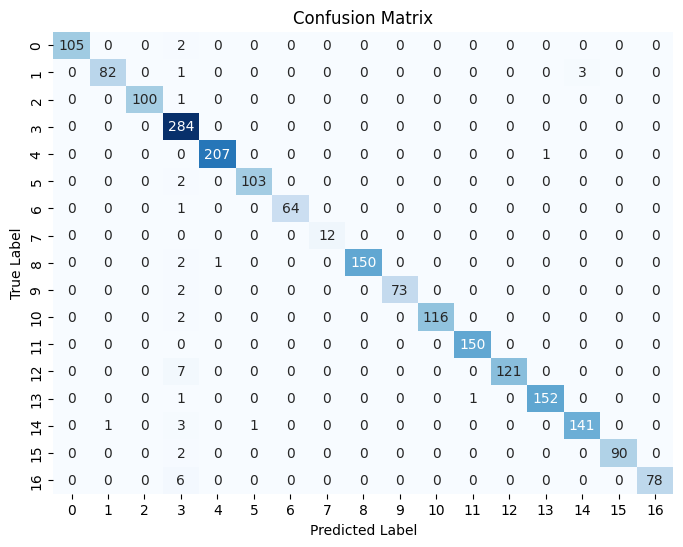

Accuracy: 0.98
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       107
           1       0.99      0.95      0.97        86
           2       1.00      0.99      1.00       101
           3       0.90      1.00      0.95       284
           4       1.00      1.00      1.00       208
           5       0.99      0.98      0.99       105
           6       1.00      0.98      0.99        65
           7       1.00      1.00      1.00        12
           8       1.00      0.98      0.99       153
           9       1.00      0.97      0.99        75
          10       1.00      0.98      0.99       118
          11       0.99      1.00      1.00       150
          12       1.00      0.95      0.97       128
          13       0.99      0.99      0.99       154
          14       0.98      0.97      0.97       146
          15       1.00      0.98      0.99        92
          16       1.00      0.93      0.96

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = pipe.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot with Seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
import pickle

# Step 1: Save the trained pipeline to a file
with open('text_classification_pipeline0.1.pkl', 'wb') as f:
    pickle.dump(pipe, f)


In [ ]:
# Step 2: Zip the pickle file
import zipfile

with zipfile.ZipFile('pipeline_model.zip', 'w') as zipf:
    zipf.write('text_classification_pipeline0.1.pkl')

In [ ]:
from google.colab import files
files.download('pipeline_model.zip')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

with open('text_classification_pipeline.pkl', 'rb') as f:
    loaded_pipe = pickle.load(f)

# Example prediction
pred = loaded_pipe.predict(["Testo di input di esempio"])
print(pred)
le.classes_[pred[0]]

[8]


'Italian'

In [ ]:
import pickle

with open('text_classification_pipeline0.1.pkl', 'rb') as f:
    loaded_pipe = pickle.load(f)

# Example prediction
pred = loaded_pipe.predict(["Sample input text"])
print(pred)
le.classes_[pred[0]]

[3]


'English'

In [ ]:
import sklearn
print(sklearn.__version__)  # Should be 1.7.0 or upgrade it


1.6.1


In [1]:
import requests

url = "https://language-detect-ml.onrender.com/predict"
data = {"text": "Bonjour, comment ça va?"}

response = requests.post(url, json=data)
result = response.json()

print(result)  # → {"language": "French"} (example)


{'language': 'French'}
